## Training and Visualizing a Decision Tree

In [20]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

In [21]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris) 

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

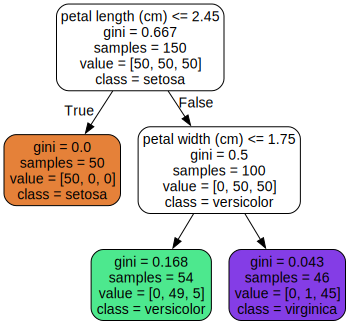

In [23]:
from graphviz import Source

Source.from_file("iris_tree.dot")

In [24]:
tree_clf.predict_proba([[5, 2.5]])

array([[0.        , 0.02173913, 0.97826087]])

## Regularization Hyperparameters

max_depth  
Maximum depth of the decision tree  

max_features  
Maximum number of features that are evaluated for splitting at each node  

max_leaf_nodes  
Maximum number of leaf nodes  

min_samples_split  
Minimum number of samples a node must have before it can be split  

min_samples_leaf  
Minimum number of samples a leaf node must have to be created  

min_weight_fraction_leaf  
Same as min_samples_leaf but expressed as a fraction of the total number of weighted instances  

Let’s test regularization on the moons dataset, introduced in Chapter 5. We’ll train one decision tree without regularization, and another with min_samples_leaf=5. Here’s the code; Figure 6-3 shows the decision boundaries of each tree:

In [25]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

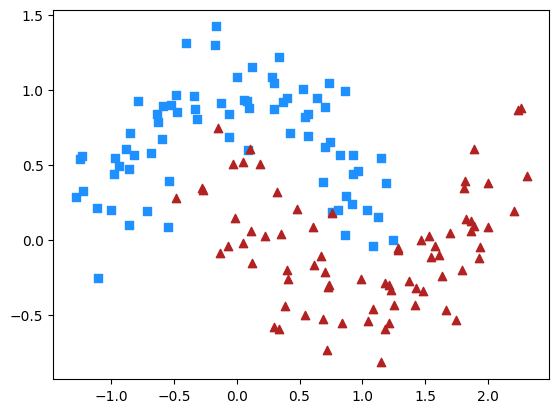

In [44]:
import matplotlib.pyplot as plt

plt.scatter(X_moons[:, 0][y_moons==0], X_moons[:, 1][y_moons==0], c="dodgerblue", marker="s")
plt.scatter(X_moons[:, 0][y_moons==1], X_moons[:, 1][y_moons==1], c="firebrick", marker="^")

In [31]:
y_moons[y_moons==0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0])

In [79]:
tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


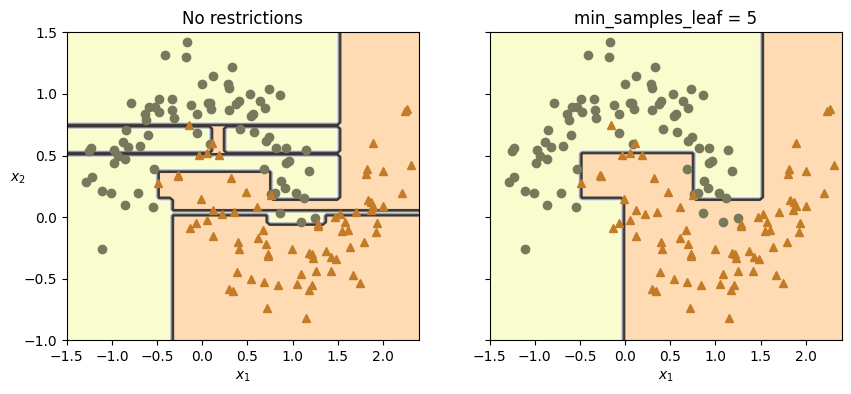

In [80]:
# copied

# extra code – this cell generates Figure 6–3
import numpy as np

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
plt.show()

In [81]:
export_graphviz(
    tree_clf1,
    out_file="iris_tree_1.dot",
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

export_graphviz(
    tree_clf2,
    out_file="iris_tree_2.dot",
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

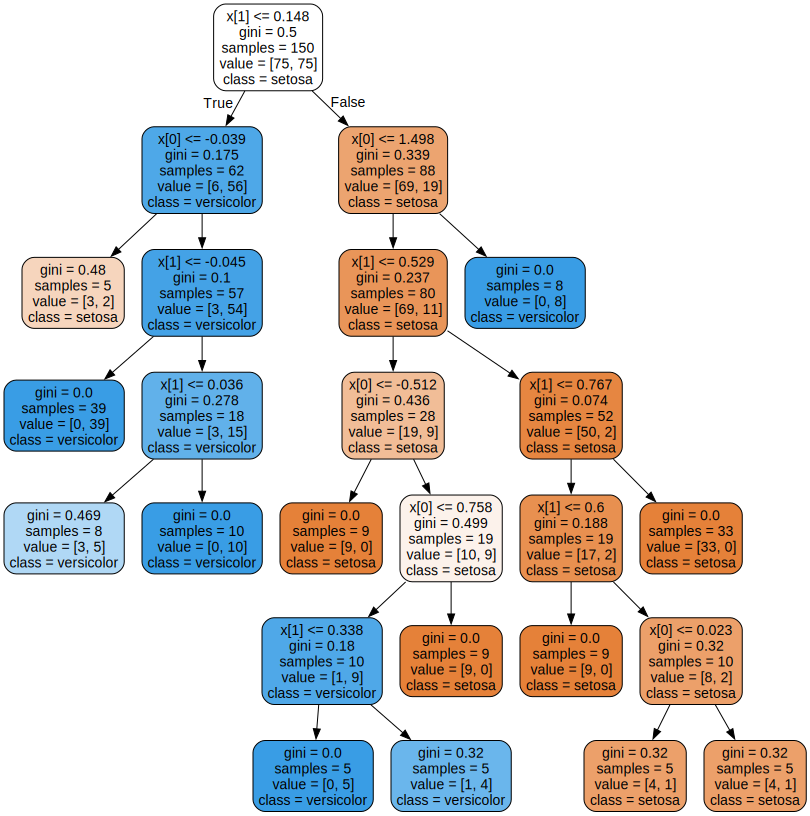

In [82]:
Source.from_file("iris_tree_2.dot")

The unregularized model on the left is clearly overfitting, and the regularized model on the right will probably generalize better. We can verify this by evaluating both trees on a test set generated using a different random seed:

In [83]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [85]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

## Regression

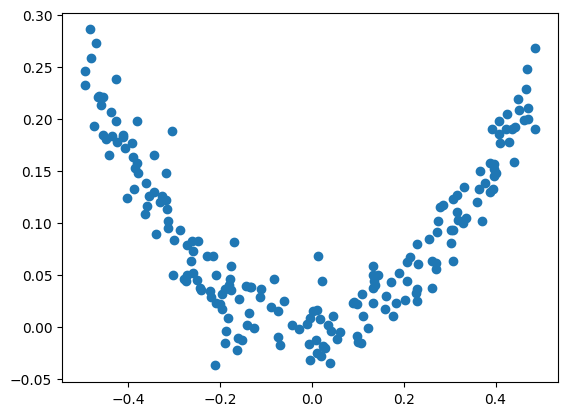

In [88]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

plt.scatter(X_quad, y_quad)

In [89]:
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Sensitivity to axis orientation

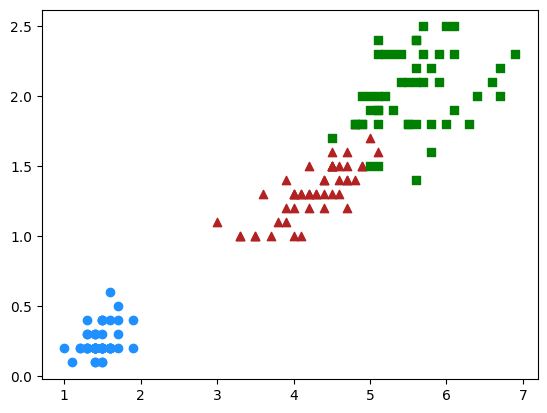

In [94]:
plt.scatter(X_iris[:, 0][y_iris==0], X_iris[:, 1][y_iris==0], c="dodgerblue", marker="o")
plt.scatter(X_iris[:, 0][y_iris==1], X_iris[:, 1][y_iris==1], c="firebrick", marker="^")
plt.scatter(X_iris[:, 0][y_iris==2], X_iris[:, 1][y_iris==2], c="green", marker="s")

In [99]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)

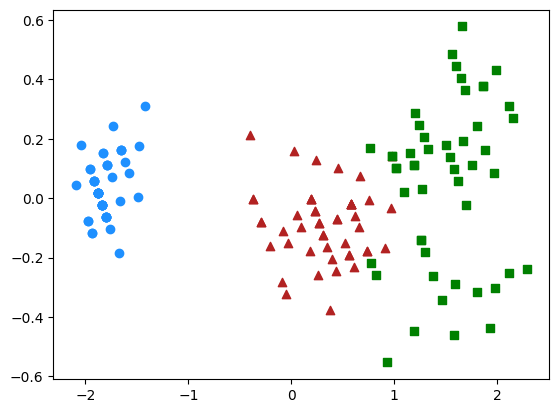

In [101]:
plt.scatter(X_iris_rotated[:, 0][y_iris==0], X_iris_rotated[:, 1][y_iris==0], c="dodgerblue", marker="o")
plt.scatter(X_iris_rotated[:, 0][y_iris==1], X_iris_rotated[:, 1][y_iris==1], c="firebrick", marker="^")
plt.scatter(X_iris_rotated[:, 0][y_iris==2], X_iris_rotated[:, 1][y_iris==2], c="green", marker="s")

In [102]:
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)


,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


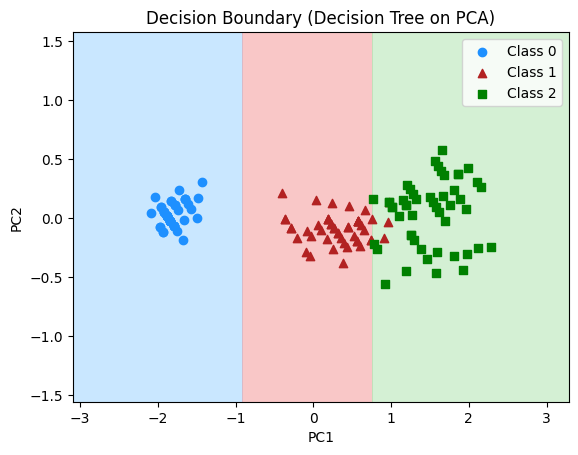

In [ ]:
# copied

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- Create mesh grid ---
x_min, x_max = X_iris_rotated[:, 0].min() - 1, X_iris_rotated[:, 0].max() + 1
y_min, y_max = X_iris_rotated[:, 1].min() - 1, X_iris_rotated[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# --- Predict over grid ---
grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree_clf_pca.predict(grid)
Z = Z.reshape(xx.shape)

# --- Custom light colormap (matches marker colors) ---
light_cmap = ListedColormap([
    "#A6D8FF",   # light dodgerblue (Class 0)
    "#F5A3A3",   # light firebrick (Class 1)
    "#B8E6B8"    # light green (Class 2)
])

# --- Plot decision regions ---
plt.contourf(xx, yy, Z, cmap=light_cmap, alpha=0.6)

# --- Plot original points ---
plt.scatter(X_iris_rotated[:, 0][y_iris==0], X_iris_rotated[:, 1][y_iris==0],
            c="dodgerblue", marker="o", label="Class 0")

plt.scatter(X_iris_rotated[:, 0][y_iris==1], X_iris_rotated[:, 1][y_iris==1],
            c="firebrick", marker="^", label="Class 1")

plt.scatter(X_iris_rotated[:, 0][y_iris==2], X_iris_rotated[:, 1][y_iris==2],
            c="green", marker="s", label="Class 2")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Decision Boundary (Decision Tree on PCA)")
plt.show()